## 02. RFM Baseline Reproduction (Chen et al. 2012)
Reproduces the RFM + K-means baseline using `valid_purchase_lines` persisted from `preprocessing.ipynb`.

In [1]:
import pandas as pd

valid_purchase_lines = pd.read_csv("../data/processed/valid_purchase_lines.csv")
customer_features_rfm = pd.read_csv("../data/processed/customer_features_rfm.csv")

print(valid_purchase_lines.shape)
print(customer_features_rfm.shape)
customer_features_rfm.head()

(349203, 15)
(3920, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12747,2,11,4196.01
2,12748,0,209,33053.19
3,12749,3,5,4090.88
4,12820,3,4,942.34


,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,91.742092,4.246429,1858.424654
std,99.533485,7.199202,7478.631256
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,298.185000
50%,50.000000,2.000000,644.975000
75%,142.000000,5.000000,1571.285000
max,373.000000,209.000000,259657.300000


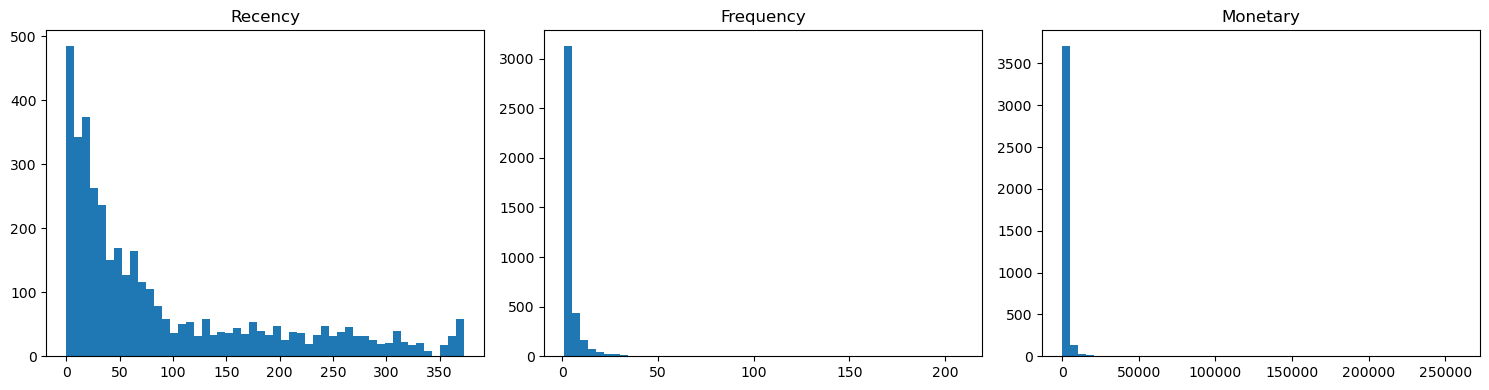

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    axes[list(['Recency','Frequency','Monetary']).index(col)].hist(customer_features_rfm[col], bins=50)
    ax.set_title(col)
plt.tight_layout()

customer_features_rfm[['Recency','Frequency','Monetary']].describe()

In [3]:
# how many customers are "one-and-done" early buyers, driving that tail bump?

one_time_early = customer_features_rfm[(customer_features_rfm['Frequency'] == 1) & (customer_features_rfm['Recency'] > 300)]
print(one_time_early.shape[0], "customers bought once and haven't returned in 300+ days")

198 customers bought once and haven't returned in 300+ days


,Recency,Frequency,Monetary
count,3.920000e+03,3.920000e+03,3.920000e+03
mean,3.987740e-17,2.904706e-16,3.516461e-16
std,1.000128e+00,1.000128e+00,1.000128e+00
min,-2.748403e+00,-9.574905e-01,-4.004447e+00
25%,-6.572134e-01,-9.574905e-01,-6.747839e-01
50%,9.628043e-02,-3.631397e-01,-5.617742e-02
75%,8.422246e-01,6.529098e-01,6.587338e-01
max,1.537807e+00,5.864515e+00,4.763099e+00


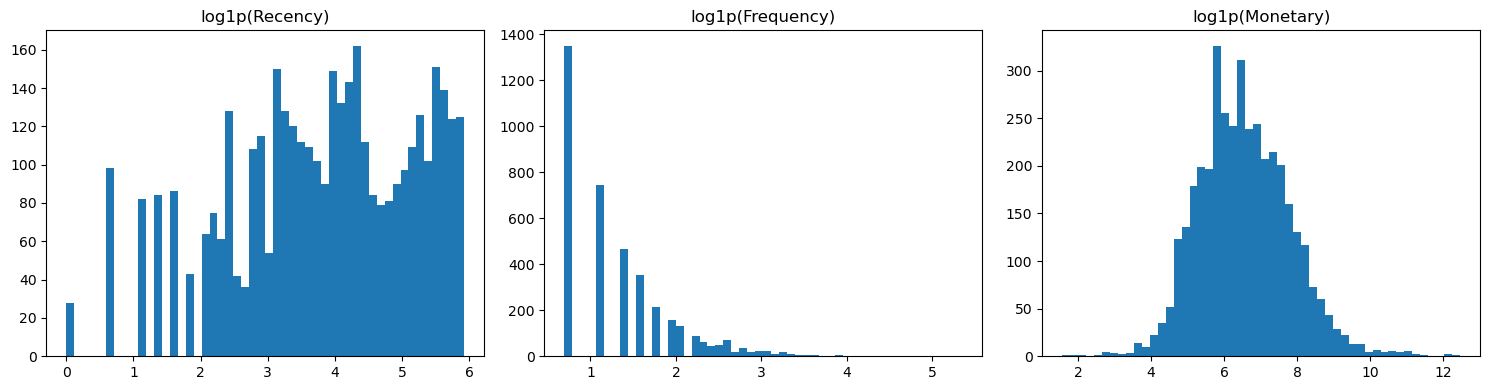

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler

# ---- FS0: raw RFM (paper-aligned baseline, no transform) ----
FS0 = customer_features_rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].copy()

# ---- FS1: log1p transform + scaling comparison ----
FS1_log = FS0.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    FS1_log[col] = np.log1p(FS1_log[col])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    ax.hist(FS1_log[col], bins=50)
    ax.set_title(f"log1p({col})")
plt.tight_layout()

# Compare StandardScaler vs RobustScaler on the log-transformed data
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

FS1_standard = FS1_log.copy()
FS1_standard[['Recency','Frequency','Monetary']] = std_scaler.fit_transform(FS1_log[['Recency','Frequency','Monetary']])

FS1_robust = FS1_log.copy()
FS1_robust[['Recency','Frequency','Monetary']] = rob_scaler.fit_transform(FS1_log[['Recency','Frequency','Monetary']])

FS1_standard[['Recency','Frequency','Monetary']].describe()

In [7]:
from scipy import stats

# Skewness after log1p, before scaling — quantifies what we saw visually
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"{col}: skew after log1p = {stats.skew(FS1_log[col]):.3f}")

# Compare how many "outlier" points remain post-scaling under each scaler,
# using a simple >3 std / >3 IQR-equivalent rule as a concrete, documented criterion
for name, df_scaled in [('StandardScaler', FS1_standard), ('RobustScaler', FS1_robust)]:
    outlier_flags = (df_scaled[['Recency','Frequency','Monetary']].abs() > 3).any(axis=1)
    print(f"{name}: {outlier_flags.sum()} customers (of {len(df_scaled)}) have |value| > 3 in at least one dimension")

Recency: skew after log1p = -0.464
Frequency: skew after log1p = 1.182
Monetary: skew after log1p = 0.373
StandardScaler: 59 customers (of 3920) have |value| > 3 in at least one dimension
RobustScaler: 9 customers (of 3920) have |value| > 3 in at least one dimension


In [8]:
FS0.to_csv("../data/processed/FS0_raw_rfm.csv", index=False)
FS1_robust.to_csv("../data/processed/FS1_log_robust_rfm.csv", index=False)